In [1]:
import CAST
import scanpy as sc
import os
import numpy as np
import warnings
import dgl
import torch
import CAST
import os
import numpy as np
import anndata as ad
import scanpy as sc
import warnings
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist
from sklearn.linear_model import LinearRegression
warnings.filterwarnings("ignore")

In [2]:
with open('/p2/zulab/jtian/data/SA/06_calculateConcentration/output_findChain/label_dfs.pkl', 'rb') as f:
    label_dfs = pickle.load(f)

In [3]:
label_dfs[0]

,0-index,0-label,0-original-x,0-original-y,15-index,15-changed-x,15-changed-y,15-label,15-original-x,15-original-y,...,45-changed-y,45-label,45-original-x,45-original-y,60-index,60-changed-x,60-changed-y,60-label,60-original-x,60-original-y
0,42344.0,0.0,50479.0,830.0,14016,51855.0,1469.0,0.0,41939.0,7710.0,...,6149.0,0.0,13939.0,7030.0,26705.0,17657.0,7767.0,0.0,4239.0,7670.0
1,35452.0,0.0,48279.0,1530.0,4581,49744.0,484.0,0.0,44099.0,8730.0,...,6071.0,0.0,14419.0,6950.0,40231.0,17525.0,6492.0,0.0,4099.0,6410.0
2,10984.0,0.0,52079.0,3850.0,4580,49764.0,485.0,0.0,44079.0,8730.0,...,6071.0,0.0,14439.0,6950.0,40232.0,17545.0,6493.0,0.0,4119.0,6410.0
3,10985.0,0.0,52099.0,3850.0,21859,51819.0,2126.0,0.0,41959.0,6990.0,...,6071.0,0.0,14459.0,6950.0,40233.0,17565.0,6493.0,0.0,4139.0,6410.0
4,10986.0,0.0,52119.0,3850.0,9249,50700.0,1001.0,0.0,43119.0,8190.0,...,6071.0,0.0,14479.0,6950.0,28990.0,13735.0,7521.0,0.0,319.0,7450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6621,NaN,NaN,NaN,NaN,48315,49033.0,4413.0,0.0,44719.0,4410.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6622,NaN,NaN,NaN,NaN,2318,50798.0,236.0,0.0,43039.0,9030.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6623,NaN,NaN,NaN,NaN,48312,49092.0,4414.0,0.0,44659.0,4410.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6624,NaN,NaN,NaN,NaN,1823,50484.0,155.0,0.0,43359.0,9110.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
for key, df in label_dfs.items():
    label_dfs[key] = df.loc[:, ~df.columns.str.contains('label')]

In [5]:
label_dfs[0]

,0-index,0-original-x,0-original-y,15-index,15-changed-x,15-changed-y,15-original-x,15-original-y,30-index,30-changed-x,...,45-index,45-changed-x,45-changed-y,45-original-x,45-original-y,60-index,60-changed-x,60-changed-y,60-original-x,60-original-y
0,42344.0,50479.0,830.0,14016,51855.0,1469.0,41939.0,7710.0,12354.0,41848.0,...,34514.0,27814.0,6149.0,13939.0,7030.0,26705.0,17657.0,7767.0,4239.0,7670.0
1,35452.0,48279.0,1530.0,4581,49744.0,484.0,44099.0,8730.0,36268.0,45130.0,...,35388.0,28291.0,6071.0,14419.0,6950.0,40231.0,17525.0,6492.0,4099.0,6410.0
2,10984.0,52079.0,3850.0,4580,49764.0,485.0,44079.0,8730.0,36269.0,45150.0,...,35389.0,28311.0,6071.0,14439.0,6950.0,40232.0,17545.0,6493.0,4119.0,6410.0
3,10985.0,52099.0,3850.0,21859,51819.0,2126.0,41959.0,6990.0,4592.0,42102.0,...,35390.0,28331.0,6071.0,14459.0,6950.0,40233.0,17565.0,6493.0,4139.0,6410.0
4,10986.0,52119.0,3850.0,9249,50700.0,1001.0,43119.0,8190.0,4591.0,42081.0,...,35391.0,28350.0,6071.0,14479.0,6950.0,28990.0,13735.0,7521.0,319.0,7450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6621,NaN,NaN,NaN,48315,49033.0,4413.0,44719.0,4410.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6622,NaN,NaN,NaN,2318,50798.0,236.0,43039.0,9030.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6623,NaN,NaN,NaN,48312,49092.0,4414.0,44659.0,4410.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6624,NaN,NaN,NaN,1823,50484.0,155.0,43359.0,9110.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
with open('/p2/zulab/jtian/data/SA/06_calculateConcentration/output_neighborsBanksy/label_dfs.pkl', 'wb') as f:
    pickle.dump(label_dfs, f)

In [27]:
with open('/p2/zulab/jtian/data/SA/06_calculateConcentration/output_neighborsBanksy/label_dfs.pkl', 'rb') as f:
    label_dfs = pickle.load(f)

In [9]:
label_dfs[0].columns

Index(['0-index', '0-original-x', '0-original-y', '15-index', '15-changed-x',
       '15-changed-y', '15-original-x', '15-original-y', '30-index',
       '30-changed-x', '30-changed-y', '30-original-x', '30-original-y',
       '45-index', '45-changed-x', '45-changed-y', '45-original-x',
       '45-original-y', '60-index', '60-changed-x', '60-changed-y',
       '60-original-x', '60-original-y'],
      dtype='object')

In [17]:
coordsLabelIntensity = pd.read_csv("/p2/zulab/jtian/data/SA/06_calculateConcentration/output_calculateByClusterLR/coordsLabelIntensity.csv")

In [11]:
coordsLabelIntensity

,Unnamed: 0,sample,cell_label,57.0346,58.0296,59.0139,67.0191,71.0137,71.0503,72.0091,...,856.5052,859.5297,860.536,863.5618,864.5684,882.5853,921.5991,923.615,985.6046,986.6105
0,1,0,5,0.208880,0.254289,0.499496,0.399597,1.607469,0.127144,0.962665,...,0.363270,0.481332,0.163471,0.000000,0.435924,0.308779,0.000000,0.000000,0.163471,0.000000
1,2,0,5,0.000000,0.223221,0.480784,0.257563,2.481191,0.000000,1.210547,...,0.712591,0.154538,0.283319,0.394930,0.463614,0.257563,0.154538,0.000000,0.120196,0.412101
2,3,0,5,0.000000,0.000000,1.175326,0.720719,0.698543,0.000000,0.155232,...,0.177408,0.155232,0.221760,0.410255,0.000000,0.000000,0.000000,0.232848,0.654191,0.343727
3,4,0,5,0.152048,0.000000,0.557510,0.000000,0.726453,0.000000,0.278755,...,0.084471,0.000000,0.194284,0.304097,0.464592,0.312544,0.278755,0.000000,0.000000,0.000000
4,5,0,5,0.000000,0.000000,0.725190,0.382195,2.587164,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.088199,0.244997,0.244997,0.195997,0.000000,0.391995,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247356,247357,60,5,2.105920,0.399399,10.329899,2.178538,39.013979,1.216350,4.302612,...,4.393384,5.627889,0.000000,3.558278,1.670212,2.723172,1.379741,1.760985,3.739823,2.360082
247357,247358,60,5,2.115093,0.459090,16.691198,1.278893,49.745672,2.672559,4.115413,...,3.148045,4.640087,0.000000,3.672719,2.623371,1.869152,1.721587,0.950972,4.230186,2.229865
247358,247359,60,5,1.906487,2.017329,14.121301,2.793224,41.831861,0.532043,6.916556,...,3.591289,5.918976,5.054406,4.655374,2.083834,1.950823,2.394192,1.773476,5.409101,2.726719
247359,247360,60,5,1.522979,3.635498,7.148176,0.000000,30.975429,1.007131,2.554675,...,8.622027,11.299522,7.393818,7.614895,4.102218,6.091916,2.309033,1.940570,5.035657,2.972266


In [18]:
adata = ad.read_h5ad("/p2/zulab/jtian/data/SA/05_CAST/output_cast9/demo1_cast9.h5ad")

In [14]:
adata.obs[['x','y']]

,x,y
SpotIndex,,
1,49939,5370
2,49959,5370
3,49979,5370
4,49999,5370
5,50019,5370
...,...,...
247357,3119,4970
247358,3139,4970
247359,3159,4970


In [15]:
coordsSampleLabelIntensity = pd.concat([adata.obs[['x','y']].reset_index(drop=True), coordsLabelIntensity.reset_index(drop=True)], axis=1)

In [16]:
coordsSampleLabelIntensity

,x,y,Unnamed: 0,sample,cell_label,57.0346,58.0296,59.0139,67.0191,71.0137,...,856.5052,859.5297,860.536,863.5618,864.5684,882.5853,921.5991,923.615,985.6046,986.6105
0,49939,5370,1,0,5,0.208880,0.254289,0.499496,0.399597,1.607469,...,0.363270,0.481332,0.163471,0.000000,0.435924,0.308779,0.000000,0.000000,0.163471,0.000000
1,49959,5370,2,0,5,0.000000,0.223221,0.480784,0.257563,2.481191,...,0.712591,0.154538,0.283319,0.394930,0.463614,0.257563,0.154538,0.000000,0.120196,0.412101
2,49979,5370,3,0,5,0.000000,0.000000,1.175326,0.720719,0.698543,...,0.177408,0.155232,0.221760,0.410255,0.000000,0.000000,0.000000,0.232848,0.654191,0.343727
3,49999,5370,4,0,5,0.152048,0.000000,0.557510,0.000000,0.726453,...,0.084471,0.000000,0.194284,0.304097,0.464592,0.312544,0.278755,0.000000,0.000000,0.000000
4,50019,5370,5,0,5,0.000000,0.000000,0.725190,0.382195,2.587164,...,0.000000,0.000000,0.000000,0.088199,0.244997,0.244997,0.195997,0.000000,0.391995,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247356,3119,4970,247357,60,5,2.105920,0.399399,10.329899,2.178538,39.013979,...,4.393384,5.627889,0.000000,3.558278,1.670212,2.723172,1.379741,1.760985,3.739823,2.360082
247357,3139,4970,247358,60,5,2.115093,0.459090,16.691198,1.278893,49.745672,...,3.148045,4.640087,0.000000,3.672719,2.623371,1.869152,1.721587,0.950972,4.230186,2.229865
247358,3159,4970,247359,60,5,1.906487,2.017329,14.121301,2.793224,41.831861,...,3.591289,5.918976,5.054406,4.655374,2.083834,1.950823,2.394192,1.773476,5.409101,2.726719
247359,3179,4970,247360,60,5,1.522979,3.635498,7.148176,0.000000,30.975429,...,8.622027,11.299522,7.393818,7.614895,4.102218,6.091916,2.309033,1.940570,5.035657,2.972266


In [17]:
coordsSampleLabelIntensity = coordsSampleLabelIntensity.rename(columns={'Unnamed: 0': 'SpotIndex'})
coordsSampleLabelIntensity.insert(0, 'SpotIndex', coordsSampleLabelIntensity.pop('SpotIndex'))

In [19]:
coordsSampleLabelIntensity.to_csv("/p2/zulab/jtian/data/SA/06_calculateConcentration/output_neighborsBanksy/coordsSampleLabelIntensity.csv",index=False)

In [28]:
coordsSampleLabelIntensity=pd.read_csv("/p2/zulab/jtian/data/SA/06_calculateConcentration/output_neighborsBanksy/coordsSampleLabelIntensity.csv")

In [29]:
intensity=pd.concat([coordsSampleLabelIntensity.loc[:,['sample','x','y']],coordsSampleLabelIntensity.iloc[:,5:]],axis=1)

In [10]:
intensity.columns

Index(['x', 'y', '57.0346', '58.0296', '59.0139', '67.0191', '71.0137',
       '71.0503', '72.0091', '72.017',
       ...
       '856.5052', '859.5297', '860.536', '863.5618', '864.5684', '882.5853',
       '921.5991', '923.615', '985.6046', '986.6105'],
      dtype='object', length=698)

In [11]:
def check_overlap_two_point_sets(df, cols_a, cols_b, round_digits=None):
    """
    cols_a, cols_b: 例如 ['0-original-x', '0-original-y']
                     和   ['15-changed-x', '15-changed-y']
    round_digits: 是否先四舍五入后再比较；None 表示不处理
    """
    tmp = df.copy()

    # 转数值
    for c in cols_a + cols_b:
        tmp[c] = pd.to_numeric(tmp[c], errors='coerce')

    # 取两组点，去掉 NA
    a = tmp[cols_a].dropna().copy()
    b = tmp[cols_b].dropna().copy()

    a.columns = ['x', 'y']
    b.columns = ['x', 'y']

    if round_digits is not None:
        a = a.round(round_digits)
        b = b.round(round_digits)

    # 去重
    a_unique = a.drop_duplicates()
    b_unique = b.drop_duplicates()

    # 求交集
    overlap = pd.merge(a_unique, b_unique, on=['x', 'y'], how='inner').drop_duplicates()

    return {
        'n_a': len(a_unique),
        'n_b': len(b_unique),
        'n_overlap': len(overlap),
        'has_overlap': len(overlap) > 0,
        'overlap_points': overlap
    }


def check_overlaps_in_label_dfs(label_dfs, round_digits=None):
    pair_defs = [
        (['0-original-x', '0-original-y'],   ['15-changed-x', '15-changed-y'], '0-original vs 15-changed'),
        (['15-original-x', '15-original-y'], ['30-changed-x', '30-changed-y'], '15-original vs 30-changed'),
        (['30-original-x', '30-original-y'], ['45-changed-x', '45-changed-y'], '30-original vs 45-changed'),
        (['45-original-x', '45-original-y'], ['60-changed-x', '60-changed-y'], '45-original vs 60-changed'),
    ]

    summary_rows = []
    overlap_points_dict = {}

    for label, df in label_dfs.items():
        overlap_points_dict[label] = {}

        for cols_a, cols_b, pair_name in pair_defs:
            res = check_overlap_two_point_sets(df, cols_a, cols_b, round_digits=round_digits)

            summary_rows.append({
                'label': label,
                'pair': pair_name,
                'n_set1': res['n_a'],
                'n_set2': res['n_b'],
                'n_overlap': res['n_overlap'],
                'has_overlap': res['has_overlap']
            })

            overlap_points_dict[label][pair_name] = res['overlap_points']

    summary_df = pd.DataFrame(summary_rows)
    return summary_df, overlap_points_dict

In [14]:
summary_df, overlap_points_dict = check_overlaps_in_label_dfs(label_dfs, round_digits=None)
print(summary_df)

    label                       pair  n_set1  n_set2  n_overlap  has_overlap
0     0.0   0-original vs 15-changed    5968    6626          3         True
1     0.0  15-original vs 30-changed    6626    5689          6         True
2     0.0  30-original vs 45-changed    5689    6232          9         True
3     0.0  45-original vs 60-changed    6232    5916          0        False
4     1.0   0-original vs 15-changed    1068    1323          0        False
..    ...                        ...     ...     ...        ...          ...
75   18.0  45-original vs 60-changed    2205    2372          0        False
76   19.0   0-original vs 15-changed    2066    2567          0        False
77   19.0  15-original vs 30-changed    2567    2037          0        False
78   19.0  30-original vs 45-changed    2037    2837          3         True
79   19.0  45-original vs 60-changed    2837    3419          0        False

[80 rows x 6 columns]


In [30]:
# =========================
# 1. 基础小工具
# =========================

def _c(sample, name):
    return f"{sample}-{name}"


def _safe_numeric_series(s):
    return pd.to_numeric(s, errors='coerce')


def _idw_weights(distances, power=1, eps=1e-12):
    distances = np.asarray(distances, dtype=float)

    zero_mask = distances <= eps
    if zero_mask.any():
        w = np.zeros_like(distances, dtype=float)
        w[zero_mask] = 1.0 / zero_mask.sum()
        return w

    inv = 1.0 / np.power(distances, power)
    return inv / inv.sum()


def _point_equal_mask(cand_xy, center_xy, exact_round_digits=None):
    """
    cand_xy: (N, 2)
    center_xy: (2,)
    """
    cand_xy = np.asarray(cand_xy, dtype=float)
    center_xy = np.asarray(center_xy, dtype=float)

    if exact_round_digits is not None:
        cand_xy = np.round(cand_xy, exact_round_digits)
        center_xy = np.round(center_xy, exact_round_digits)

    return np.all(cand_xy == center_xy, axis=1)


def _weighted_sum_ignore_nan(values_2d, weights):
    """
    values_2d: shape (k, n_mz)
    weights: shape (k,)
    对每个 mz 列分别做忽略 NaN 的加权平均
    """
    values_2d = np.asarray(values_2d, dtype=float)
    weights = np.asarray(weights, dtype=float)

    valid = np.isfinite(values_2d)
    w2 = weights[:, None] * valid

    numerator = np.nansum(values_2d * weights[:, None], axis=0)
    denominator = np.sum(w2, axis=0)

    out = np.full(values_2d.shape[1], np.nan, dtype=float)
    good = denominator > 0
    out[good] = numerator[good] / denominator[good]
    return out


def _get_sample_changed_cols(df, sample):
    """
    返回输出里要用的 changed 坐标列名。
    若 sample 没有 changed-x/y（例如 sample 0），则用 original-x/y 顶上。
    """
    cx = _c(sample, 'changed-x')
    cy = _c(sample, 'changed-y')
    ox = _c(sample, 'original-x')
    oy = _c(sample, 'original-y')

    if cx in df.columns and cy in df.columns:
        return cx, cy
    else:
        return ox, oy


def _get_mz_cols(intensity_df):
    return list(intensity_df.columns[2:])


def _layer_cols_for_samples(df, sample_list):
    """
    按 sample_list 顺序返回 layer 列：
    例如 sample_list=[30,45,60] -> 所有 *-30, 再所有 *-45, 再所有 *-60
    """
    cols = []
    for s in sample_list:
        suffix = f"-{s}"
        these = [c for c in df.columns if c.endswith(suffix)]
        cols.extend(these)
    return cols


def _strip_internal_cols(df):
    return df[[c for c in df.columns if not c.startswith("__")]].copy()


def _reorder_output_columns(df, anchor_sample, layer_samples):
    """
    前四列固定为 anchor_sample 的 changed/original 坐标
    后面按 layer_samples 顺序放各 sample 的 mz 列
    """
    out = df.copy()

    coord_cols = [
        _c(anchor_sample, 'changed-x'),
        _c(anchor_sample, 'changed-y'),
        _c(anchor_sample, 'original-x'),
        _c(anchor_sample, 'original-y'),
    ]

    layer_cols = []
    for s in layer_samples:
        layer_cols.extend([c for c in out.columns if c.endswith(f"-{s}")])

    keep = coord_cols + layer_cols
    keep = [c for c in keep if c in out.columns]
    return out.loc[:, keep].copy()


# =========================
# 2. 构造“某个样本自身点位上的实测 intensity 数据框”
# =========================

def build_observed_frame_label_dfs(label_dfs, intensity_df, sample):
    """
    在 sample 自己的点位上，构造一个内部数据框：
    - 内部列: __label, __point_index
    - 坐标列: sample-changed-x/y, sample-original-x/y
    - 强度列: mz-sample

    说明：
    - 若 sample 没有 changed-x/y（例如 0），自动用 original-x/y 填到 changed-x/y
    - intensity_df 默认前两列是 x,y，后面全是 mz
    - 默认 sample-index 可直接对应 intensity_df.iloc[index]
    """
    rows = []
    mz_cols = _get_mz_cols(intensity_df)

    idx_col = _c(sample, 'index')
    ox_col = _c(sample, 'original-x')
    oy_col = _c(sample, 'original-y')
    cx_src_col, cy_src_col = _get_sample_changed_cols(next(iter(label_dfs.values())), sample)

    intensity_num = intensity_df.copy()
    intensity_num.iloc[:, 0] = pd.to_numeric(intensity_num.iloc[:, 0], errors='coerce')
    intensity_num.iloc[:, 1] = pd.to_numeric(intensity_num.iloc[:, 1], errors='coerce')
    for c in mz_cols:
        intensity_num[c] = pd.to_numeric(intensity_num[c], errors='coerce')

    for label, df in label_dfs.items():
        tmp = df.copy()

        need_cols = [idx_col, ox_col, oy_col]
        for c in need_cols:
            if c not in tmp.columns:
                raise ValueError(f"label={label} 缺少列 {c}")

        tmp[idx_col] = _safe_numeric_series(tmp[idx_col])
        tmp[ox_col] = _safe_numeric_series(tmp[ox_col])
        tmp[oy_col] = _safe_numeric_series(tmp[oy_col])

        if cx_src_col in tmp.columns:
            tmp[cx_src_col] = _safe_numeric_series(tmp[cx_src_col])
        if cy_src_col in tmp.columns:
            tmp[cy_src_col] = _safe_numeric_series(tmp[cy_src_col])

        mask = tmp[[idx_col, ox_col, oy_col]].notna().all(axis=1)

        for row_i in tmp.index[mask]:
            point_idx = int(tmp.loc[row_i, idx_col])

            rec = {
                "__label": label,
                "__point_index": point_idx,

                _c(sample, 'changed-x'): float(tmp.loc[row_i, cx_src_col]) if cx_src_col in tmp.columns else float(tmp.loc[row_i, ox_col]),
                _c(sample, 'changed-y'): float(tmp.loc[row_i, cy_src_col]) if cy_src_col in tmp.columns else float(tmp.loc[row_i, oy_col]),
                _c(sample, 'original-x'): float(tmp.loc[row_i, ox_col]),
                _c(sample, 'original-y'): float(tmp.loc[row_i, oy_col]),
            }

            # intensity
            if 0 <= point_idx < len(intensity_num):
                vec = intensity_num.iloc[point_idx][mz_cols].to_numpy(dtype=float)
            else:
                vec = np.full(len(mz_cols), np.nan)

            for j, mz in enumerate(mz_cols):
                rec[f"{mz}-{sample}"] = vec[j]

            rows.append(rec)

    out = pd.DataFrame(rows)

    if len(out) == 0:
        return out

    # 去重：label + point_index 只保留第一条
    out = out.drop_duplicates(subset=["__label", "__point_index"], keep="first").reset_index(drop=True)
    return out


# =========================
# 3. 利用 sample_b 点位上的已有 layer，去预测这些 layer 在 sample_a 点位上的值
# =========================

def propagate_layers_from_frame(
    label_dfs,
    source_frame,
    source_samples,
    sample_a,
    sample_b,
    k=4,
    power=1,
    exact_round_digits=None
):
    """
    用 sample_a-original 作为中心点，
    在同一个 label 内，用 sample_b-changed 做匹配点，
    把 source_frame（位于 sample_b 点位上）的所有 layer
    预测到 sample_a 点位上。

    source_frame 必须是“sample_b 点位上的数据框”，内部至少要有：
    - __label
    - __point_index   (它对应 sample_b-index)
    - 若干 layer 列，如 mz-45, mz-60
    """

    if len(source_frame) == 0:
        return pd.DataFrame()

    layer_cols = _layer_cols_for_samples(source_frame, source_samples)

    idx_a = _c(sample_a, 'index')
    ox_a = _c(sample_a, 'original-x')
    oy_a = _c(sample_a, 'original-y')
    cx_a_src, cy_a_src = _get_sample_changed_cols(next(iter(label_dfs.values())), sample_a)

    idx_b = _c(sample_b, 'index')
    cx_b = _c(sample_b, 'changed-x')
    cy_b = _c(sample_b, 'changed-y')

    out_rows = []

    for label, df in label_dfs.items():
        tmp = df.copy()

        # A 端
        for c in [idx_a, ox_a, oy_a]:
            if c not in tmp.columns:
                raise ValueError(f"label={label} 缺少列 {c}")
            tmp[c] = _safe_numeric_series(tmp[c])

        if cx_a_src in tmp.columns:
            tmp[cx_a_src] = _safe_numeric_series(tmp[cx_a_src])
        if cy_a_src in tmp.columns:
            tmp[cy_a_src] = _safe_numeric_series(tmp[cy_a_src])

        # B 端
        for c in [idx_b, cx_b, cy_b]:
            if c not in tmp.columns:
                raise ValueError(f"label={label} 缺少列 {c}")
            tmp[c] = _safe_numeric_series(tmp[c])

        # 当前 label 下 sample_b 点位上的 source 信息
        src_sub = source_frame[source_frame["__label"] == label].copy()
        if len(src_sub) > 0:
            src_sub = src_sub.drop_duplicates(subset="__point_index", keep="first").set_index("__point_index")
            src_idx_set = set(src_sub.index.tolist())
        else:
            src_idx_set = set()

        # 当前 label 下的中心点（sample_a-original）
        center_mask = tmp[[idx_a, ox_a, oy_a]].notna().all(axis=1)

        # 当前 label 下的候选点（sample_b-changed），并且必须在 source_frame 中有 layer 值
        cand_mask = tmp[[idx_b, cx_b, cy_b]].notna().all(axis=1)

        cand_rows_all = tmp.index[cand_mask].to_numpy()
        cand_idx_all = tmp.loc[cand_mask, idx_b].astype(int).to_numpy()
        cand_xy_all = tmp.loc[cand_mask, [cx_b, cy_b]].to_numpy(dtype=float)

        keep_pos = [i for i, idxv in enumerate(cand_idx_all) if idxv in src_idx_set]

        if len(keep_pos) > 0:
            cand_rows = cand_rows_all[keep_pos]
            cand_idx = cand_idx_all[keep_pos]
            cand_xy = cand_xy_all[keep_pos]
            cand_values = src_sub.loc[cand_idx, layer_cols].to_numpy(dtype=float)
        else:
            cand_rows = np.array([], dtype=int)
            cand_idx = np.array([], dtype=int)
            cand_xy = np.empty((0, 2), dtype=float)
            cand_values = np.empty((0, len(layer_cols)), dtype=float)

        for row_a in tmp.index[center_mask]:
            point_idx_a = int(tmp.loc[row_a, idx_a])
            center_xy = tmp.loc[row_a, [ox_a, oy_a]].to_numpy(dtype=float)

            base_rec = {
                "__label": label,
                "__point_index": point_idx_a,

                _c(sample_a, 'changed-x'): float(tmp.loc[row_a, cx_a_src]) if cx_a_src in tmp.columns else float(tmp.loc[row_a, ox_a]),
                _c(sample_a, 'changed-y'): float(tmp.loc[row_a, cy_a_src]) if cy_a_src in tmp.columns else float(tmp.loc[row_a, oy_a]),
                _c(sample_a, 'original-x'): float(tmp.loc[row_a, ox_a]),
                _c(sample_a, 'original-y'): float(tmp.loc[row_a, oy_a]),
            }

            # 若没有任何可用候选点，则全 NaN
            if len(cand_idx) == 0:
                pred_vec = np.full(len(layer_cols), np.nan)
                rec = base_rec.copy()
                for j, col in enumerate(layer_cols):
                    rec[col] = pred_vec[j]
                out_rows.append(rec)
                continue

            # 先查完全重合点
            exact_mask = _point_equal_mask(
                cand_xy=cand_xy,
                center_xy=center_xy,
                exact_round_digits=exact_round_digits
            )
            exact_pos = np.where(exact_mask)[0]

            if len(exact_pos) > 0:
                p = exact_pos[0]
                pred_vec = cand_values[p, :].copy()
            else:
                diff = cand_xy - center_xy[None, :]
                dist = np.sqrt(np.sum(diff * diff, axis=1))

                topk = min(k, len(cand_idx))
                pos = np.argsort(dist)[:topk]

                d = dist[pos]
                w = _idw_weights(d, power=power)

                nbr_values = cand_values[pos, :]
                pred_vec = _weighted_sum_ignore_nan(nbr_values, w)

            rec = base_rec.copy()
            for j, col in enumerate(layer_cols):
                rec[col] = pred_vec[j]
            out_rows.append(rec)

    out = pd.DataFrame(out_rows)
    if len(out) == 0:
        return out

    out = out.drop_duplicates(subset=["__label", "__point_index"], keep="first").reset_index(drop=True)
    return out


# =========================
# 4. 合并“当前样本实测层”与“从后一个样本传播来的层”
# =========================

def merge_anchor_observed_and_predicted(
    observed_frame,
    predicted_frame,
    anchor_sample,
    layer_samples_order
):
    """
    observed_frame: 当前 anchor 样本自己的实测层（例如 30 点上的 mz-30）
    predicted_frame: 从后一个样本传播来的层（例如 30 点上的 mz-45, mz-60）
    """
    key_cols = ["__label", "__point_index"]

    coord_cols = [
        _c(anchor_sample, 'changed-x'),
        _c(anchor_sample, 'changed-y'),
        _c(anchor_sample, 'original-x'),
        _c(anchor_sample, 'original-y'),
    ]

    obs_keep = key_cols + coord_cols + [c for c in observed_frame.columns if c.endswith(f"-{anchor_sample}")]
    pred_keep = key_cols + [c for c in predicted_frame.columns if c not in key_cols + coord_cols]

    obs2 = observed_frame.loc[:, [c for c in obs_keep if c in observed_frame.columns]].copy()
    pred2 = predicted_frame.loc[:, [c for c in pred_keep if c in predicted_frame.columns]].copy()

    merged = obs2.merge(pred2, on=key_cols, how="left")

    # 调整列顺序
    layer_cols = []
    for s in layer_samples_order:
        layer_cols.extend([c for c in merged.columns if c.endswith(f"-{s}")])

    final_cols = key_cols + coord_cols + layer_cols
    final_cols = [c for c in final_cols if c in merged.columns]
    merged = merged.loc[:, final_cols].copy()

    return merged


# =========================
# 5. 总控函数：从后往前逐级传播
# =========================

def cascade_predict_backward(
    label_dfs,
    intensity_map,
    samples=(0, 15, 30, 45, 60),
    k=4,
    power=1,
    exact_round_digits=None,
    include_first_sample_observed=False
):
    """
    逐级回推：
    60 -> 45 -> 30 -> 15 -> 0

    参数
    ----
    label_dfs : dict[label] = DataFrame
    intensity_map : dict[sample] = intensity_df
                    例如 {0:intensity0, 15:intensity15, 30:intensity30, 45:intensity45, 60:intensity60}
    samples : 样本顺序，默认 (0,15,30,45,60)
    k : kNN 个数
    power : IDW 权重幂次
    exact_round_digits : 完全重合时是否先 round；None 表示严格完全相等
    include_first_sample_observed : 最终 sample0 的输出里是否也带上 mz-0
                                    默认 False，即只保留 15/30/45/60

    返回
    ----
    display_frames : 面向使用的数据框字典（已去掉内部列）
                     键是样本号，例如 display_frames[45], display_frames[30], ... , display_frames[0]
    internal_frames : 内部数据框字典（保留 __label, __point_index，便于继续运算）
    """

    samples = list(samples)
    if len(samples) < 2:
        raise ValueError("samples 至少需要两个样本")

    for s in samples:
        if s not in intensity_map:
            raise ValueError(f"intensity_map 缺少样本 {s}")

    display_frames = {}
    internal_frames = {}

    # 起点：最后一个样本（例如 60）自身点位上的实测层
    last_sample = samples[-1]
    current_internal = build_observed_frame_label_dfs(label_dfs, intensity_map[last_sample], last_sample)
    current_layer_samples = [last_sample]

    internal_frames[last_sample] = current_internal
    display_frames[last_sample] = _reorder_output_columns(
        _strip_internal_cols(current_internal),
        anchor_sample=last_sample,
        layer_samples=current_layer_samples
    )

    # 从后往前逐级传播
    for i in range(len(samples) - 2, -1, -1):
        sample_a = samples[i]
        sample_b = samples[i + 1]

        # 先把 current_internal（位于 sample_b 点位上）传播到 sample_a 点位上
        predicted_on_a = propagate_layers_from_frame(
            label_dfs=label_dfs,
            source_frame=current_internal,
            source_samples=current_layer_samples,
            sample_a=sample_a,
            sample_b=sample_b,
            k=k,
            power=power,
            exact_round_digits=exact_round_digits
        )

        # 是否把 sample_a 自己的实测层并进来
        is_first = (i == 0)
        if is_first and (not include_first_sample_observed):
            merged_internal = predicted_on_a.copy()
            merged_layer_samples = current_layer_samples.copy()
        else:
            observed_a = build_observed_frame_label_dfs(label_dfs, intensity_map[sample_a], sample_a)
            merged_layer_samples = [sample_a] + current_layer_samples

            merged_internal = merge_anchor_observed_and_predicted(
                observed_frame=observed_a,
                predicted_frame=predicted_on_a,
                anchor_sample=sample_a,
                layer_samples_order=merged_layer_samples
            )

        current_internal = merged_internal
        current_layer_samples = merged_layer_samples

        internal_frames[sample_a] = current_internal
        display_frames[sample_a] = _reorder_output_columns(
            _strip_internal_cols(current_internal),
            anchor_sample=sample_a,
            layer_samples=current_layer_samples
        )

    return display_frames, internal_frames

In [21]:
intensity

,sample,x,y,57.0346,58.0296,59.0139,67.0191,71.0137,71.0503,72.0091,...,856.5052,859.5297,860.536,863.5618,864.5684,882.5853,921.5991,923.615,985.6046,986.6105
0,0,49939,5370,0.208880,0.254289,0.499496,0.399597,1.607469,0.127144,0.962665,...,0.363270,0.481332,0.163471,0.000000,0.435924,0.308779,0.000000,0.000000,0.163471,0.000000
1,0,49959,5370,0.000000,0.223221,0.480784,0.257563,2.481191,0.000000,1.210547,...,0.712591,0.154538,0.283319,0.394930,0.463614,0.257563,0.154538,0.000000,0.120196,0.412101
2,0,49979,5370,0.000000,0.000000,1.175326,0.720719,0.698543,0.000000,0.155232,...,0.177408,0.155232,0.221760,0.410255,0.000000,0.000000,0.000000,0.232848,0.654191,0.343727
3,0,49999,5370,0.152048,0.000000,0.557510,0.000000,0.726453,0.000000,0.278755,...,0.084471,0.000000,0.194284,0.304097,0.464592,0.312544,0.278755,0.000000,0.000000,0.000000
4,0,50019,5370,0.000000,0.000000,0.725190,0.382195,2.587164,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.088199,0.244997,0.244997,0.195997,0.000000,0.391995,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247356,60,3119,4970,2.105920,0.399399,10.329899,2.178538,39.013979,1.216350,4.302612,...,4.393384,5.627889,0.000000,3.558278,1.670212,2.723172,1.379741,1.760985,3.739823,2.360082
247357,60,3139,4970,2.115093,0.459090,16.691198,1.278893,49.745672,2.672559,4.115413,...,3.148045,4.640087,0.000000,3.672719,2.623371,1.869152,1.721587,0.950972,4.230186,2.229865
247358,60,3159,4970,1.906487,2.017329,14.121301,2.793224,41.831861,0.532043,6.916556,...,3.591289,5.918976,5.054406,4.655374,2.083834,1.950823,2.394192,1.773476,5.409101,2.726719
247359,60,3179,4970,1.522979,3.635498,7.148176,0.000000,30.975429,1.007131,2.554675,...,8.622027,11.299522,7.393818,7.614895,4.102218,6.091916,2.309033,1.940570,5.035657,2.972266


In [31]:
intensity_map = {
    s: df.drop(columns='sample').reset_index(drop=True)
    for s, df in intensity.groupby('sample')
}


In [33]:
display_frames, internal_frames = cascade_predict_backward(
    label_dfs=label_dfs,
    intensity_map=intensity_map,
    samples=(0, 15, 30, 45, 60),
    k=4,
    power=1,
    exact_round_digits=None,      # 完全严格相等才算“直接对应”
    include_first_sample_observed=True
)

In [34]:
df45 = display_frames[45]
df30 = display_frames[30]
df15 = display_frames[15]
df0  = display_frames[0]

In [35]:
df0

,0-changed-x,0-changed-y,0-original-x,0-original-y,57.0346-0,58.0296-0,59.0139-0,67.0191-0,71.0137-0,71.0503-0,...,856.5052-60,859.5297-60,860.536-60,863.5618-60,864.5684-60,882.5853-60,921.5991-60,923.615-60,985.6046-60,986.6105-60
0,50479.0,830.0,50479.0,830.0,1.193864,2.956235,6.509403,1.222290,24.019412,0.000000,...,4.458321,7.439918,5.045978,5.402608,3.022916,1.961289,1.909996,2.140921,1.514927,1.878630
1,48279.0,1530.0,48279.0,1530.0,1.678438,1.715327,6.935086,0.590220,15.327278,1.014441,...,4.268904,7.806781,5.219364,4.649962,3.418300,2.136128,1.987494,2.112174,2.013077,1.175471
2,52079.0,3850.0,52079.0,3850.0,0.665334,1.376554,4.749111,0.504736,19.570007,0.000000,...,4.144183,7.863453,5.036491,5.737700,3.317050,2.588634,2.192316,2.292863,1.974372,1.018226
3,52099.0,3850.0,52099.0,3850.0,0.000000,0.402024,3.690006,0.402024,13.338582,0.258444,...,4.134065,7.916073,5.010221,5.753034,3.125162,2.625861,2.187974,2.185881,1.880850,0.952316
4,52119.0,3850.0,52119.0,3850.0,0.000000,2.013954,3.365423,1.006977,10.599756,0.000000,...,4.136530,7.903557,5.016497,5.749817,3.171030,2.617202,2.189046,2.211090,1.902972,0.968005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47390,49319.0,3250.0,49319.0,3250.0,1.143931,1.085268,6.159627,4.311739,20.180112,0.000000,...,5.475479,7.616328,5.036602,4.856946,3.474125,2.484892,2.469656,2.700313,2.058217,1.934920
47391,49739.0,1170.0,49739.0,1170.0,2.073597,1.334729,3.289153,0.000000,17.113130,0.000000,...,4.146208,6.373845,3.542760,7.194497,3.377728,2.224432,1.727407,1.972915,1.926811,1.687076
47392,49759.0,1170.0,49759.0,1170.0,0.679172,2.595406,6.524900,0.000000,22.097338,0.751940,...,4.151284,6.390133,3.534969,7.184368,3.368634,2.228318,1.709452,1.955734,1.927056,1.690352
47393,50039.0,350.0,50039.0,350.0,0.626969,0.773261,2.716864,1.734613,20.773557,0.000000,...,4.413863,7.128390,5.463096,7.377593,3.599465,1.592679,1.754536,2.561087,1.420819,1.351064


In [39]:
out_dir = '/p2/zulab/jtian/data/SA/06_calculateConcentration/output_neighborsBanksy/'
os.makedirs(out_dir, exist_ok=True)

with open(os.path.join(out_dir, 'display_frames.pkl'), 'wb') as f:
    pickle.dump(display_frames, f)

with open(os.path.join(out_dir, 'internal_frames.pkl'), 'wb') as f:
    pickle.dump(internal_frames, f)

In [39]:
out_dir = '/p2/zulab/jtian/data/SA/06_calculateConcentration/output_neighborsBanksy/'
with open(os.path.join(out_dir, 'display_frames.pkl'), 'rb') as f:
    display_frames = pickle.load(f)

with open(os.path.join(out_dir, 'internal_frames.pkl'), 'rb') as f:
    internal_frames = pickle.load(f)

In [38]:
# =========================================
# 1. 基础函数：邻域图与平滑
# =========================================

def _compute_knn_indices_and_distances(xy, k=15):
    """
    xy: shape (n, 2)
    返回每个点最近的 k 个邻居（不含自己）的索引和距离
    """
    xy = np.asarray(xy, dtype=float)
    n = xy.shape[0]

    diff = xy[:, None, :] - xy[None, :, :]
    dist = np.sqrt(np.sum(diff * diff, axis=2))

    # 不把自己作为邻居
    np.fill_diagonal(dist, np.inf)

    k_eff = min(k, max(n - 1, 1))
    nbr_idx = np.argsort(dist, axis=1)[:, :k_eff]
    nbr_dist = np.take_along_axis(dist, nbr_idx, axis=1)

    return nbr_idx, nbr_dist


def _make_neighbor_weights(nbr_dist, decay='scaled_gaussian', eps=1e-12):
    """
    根据邻居距离构建权重
    decay:
    - 'scaled_gaussian'
    - 'uniform'
    - 'reciprocal'
    """
    d = np.asarray(nbr_dist, dtype=float)

    if decay == 'uniform':
        w = np.ones_like(d, dtype=float)

    elif decay == 'reciprocal':
        w = 1.0 / np.maximum(d, eps)

    elif decay == 'scaled_gaussian':
        # 每个点用第 k 个邻居距离作为局部 sigma
        sigma = d[:, -1][:, None]
        sigma = np.maximum(sigma, eps)
        w = np.exp(-(d ** 2) / (2.0 * sigma ** 2))

    else:
        raise ValueError("decay 只能是 'scaled_gaussian', 'uniform', 'reciprocal'")

    # 行归一化
    row_sum = np.sum(w, axis=1, keepdims=True)
    row_sum = np.maximum(row_sum, eps)
    w = w / row_sum
    return w


def _neighbor_mean_matrix(X, nbr_idx, W):
    """
    对 X 计算邻域均值矩阵 M
    X: (n, p)
    nbr_idx: (n, k)
    W: (n, k)

    自动忽略 NaN，并对每一列按有效邻居重新归一化
    """
    X = np.asarray(X, dtype=float)
    X_neigh = X[nbr_idx, :]      # (n, k, p)
    valid = np.isfinite(X_neigh)

    numerator = np.nansum(X_neigh * W[:, :, None], axis=1)
    denominator = np.sum(W[:, :, None] * valid, axis=1)

    M = np.full_like(numerator, np.nan, dtype=float)
    good = denominator > 0
    M[good] = numerator[good] / denominator[good]
    return M


def _split_feature_name(col):
    """
    把 '57.0346-45' 拆成 ('57.0346', 45)
    """
    if '-' not in col:
        return None, None
    mz, sample = col.rsplit('-', 1)
    if not sample.isdigit():
        return None, None
    return mz, int(sample)


def _auto_feature_cols(df):
    """
    自动识别所有 mz-sample 列
    """
    cols = []
    for c in df.columns:
        mz, sample = _split_feature_name(c)
        if mz is not None:
            cols.append(c)
    return cols


def banksy_like_smooth_display0(
    df0,
    coord_cols=('0-original-x', '0-original-y'),
    feature_cols=None,
    k=15,
    lambda_=0.2,
    decay='scaled_gaussian',
    use_log1p=True,
    preserve_missing=True
):
    """
    对 display_frames[0] 做 BANKSY-inspired 微环境平滑

    X* = (1-lambda) X + lambda M

    参数
    ----
    df0 : display_frames[0]
    coord_cols : 用于建邻域图的坐标列
    feature_cols : 要平滑的列；None 表示自动识别所有 mz-sample 列
    k : 邻居数
    lambda_ : 微环境权重
    decay : 权重衰减方式
    use_log1p : 是否先 log1p 再平滑
    preserve_missing : 原始缺失是否保持缺失

    返回
    ----
    smoothed_df : 平滑后的表
    neighbor_mean_df : 邻域均值表 M
    weights_df : 邻居与权重明细
    """
    if not (0 <= lambda_ <= 1):
        raise ValueError("lambda_ 必须在 0 到 1 之间")

    out = df0.copy()
    xcol, ycol = coord_cols

    out[xcol] = pd.to_numeric(out[xcol], errors='coerce')
    out[ycol] = pd.to_numeric(out[ycol], errors='coerce')

    if feature_cols is None:
        feature_cols = _auto_feature_cols(out)

    for c in feature_cols:
        out[c] = pd.to_numeric(out[c], errors='coerce')

    valid_mask = out[[xcol, ycol]].notna().all(axis=1)
    valid_index = out.index[valid_mask].to_numpy()

    if len(valid_index) < 2:
        raise ValueError("有效坐标点少于 2 个，无法建邻域图")

    xy = out.loc[valid_mask, [xcol, ycol]].to_numpy(dtype=float)
    X_raw = out.loc[valid_mask, feature_cols].to_numpy(dtype=float)

    if use_log1p:
        if np.nanmin(X_raw) < 0:
            raise ValueError("检测到负 intensity，不能直接做 log1p；请先检查数据或设 use_log1p=False")
        X = np.log1p(X_raw)
    else:
        X = X_raw.copy()

    nbr_idx, nbr_dist = _compute_knn_indices_and_distances(xy, k=k)
    W = _make_neighbor_weights(nbr_dist, decay=decay)
    M = _neighbor_mean_matrix(X, nbr_idx, W)

    # 平滑
    X_smooth = np.where(
        np.isfinite(X) & np.isfinite(M),
        (1 - lambda_) * X + lambda_ * M,
        np.where(np.isfinite(X), X, M)
    )

    if preserve_missing:
        X_smooth[~np.isfinite(X)] = np.nan

    # 变回原始尺度
    if use_log1p:
        X_smooth_raw = np.expm1(X_smooth)
        M_raw = np.expm1(M)
    else:
        X_smooth_raw = X_smooth
        M_raw = M

    smoothed_df = out.copy()
    smoothed_df.loc[valid_mask, feature_cols] = X_smooth_raw

    neighbor_mean_df = out.copy()
    neighbor_mean_df.loc[:, feature_cols] = np.nan
    neighbor_mean_df.loc[valid_mask, feature_cols] = M_raw

    # 邻居权重表
    weight_records = []
    for i in range(len(valid_index)):
        center_row = int(valid_index[i])
        for j in range(nbr_idx.shape[1]):
            neigh_local = int(nbr_idx[i, j])
            neigh_row = int(valid_index[neigh_local])
            weight_records.append({
                'center_row': center_row,
                'neighbor_rank': j + 1,
                'neighbor_row': neigh_row,
                'distance': float(nbr_dist[i, j]),
                'weight': float(W[i, j]),
            })
    weights_df = pd.DataFrame(weight_records)

    return smoothed_df, neighbor_mean_df, weights_df


# =========================================
# 2. 标准曲线拟合：每一行、每一个 mz
# =========================================

def _safe_line_fit_and_corr(x, y, min_n=3):
    """
    对一组 (x, y) 做线性拟合并返回 Pearson / R² / slope / intercept

    x: 样本编号，例如 [0,15,30,45,60]
    y: 同一行、同一 mz 在不同样本上的 intensity
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x2 = x[mask]
    y2 = y[mask]
    n = len(x2)

    if n < min_n:
        return {
            'n': n,
            'pearson_r': np.nan,
            'r2': np.nan,
            'slope': np.nan,
            'intercept': np.nan
        }

    # x 或 y 无方差时，相关性和回归都没有意义
    if np.nanstd(x2) == 0 or np.nanstd(y2) == 0:
        return {
            'n': n,
            'pearson_r': np.nan,
            'r2': np.nan,
            'slope': np.nan,
            'intercept': np.nan
        }

    # Pearson
    r = np.corrcoef(x2, y2)[0, 1]

    # 一元线性回归 y = slope * x + intercept
    slope, intercept = np.polyfit(x2, y2, 1)

    # R²
    y_hat = slope * x2 + intercept
    ss_res = np.sum((y2 - y_hat) ** 2)
    ss_tot = np.sum((y2 - np.mean(y2)) ** 2)
    r2 = np.nan if ss_tot == 0 else 1 - ss_res / ss_tot

    return {
        'n': n,
        'pearson_r': float(r),
        'r2': float(r2),
        'slope': float(slope),
        'intercept': float(intercept)
    }


def evaluate_standard_curve_before_after(
    df_before,
    df_after,
    samples=(0, 15, 30, 45, 60),
    mz_list=None,
    min_n=3
):
    """
    对每个点位、每个 mz：
    把 mz-0, mz-15, mz-30, mz-45, mz-60 视为 y，
    把 0,15,30,45,60 视为 x，
    分别在平滑前后做线性拟合和 Pearson 相关性比较。

    返回
    ----
    detail_df : 每一行每一个 mz 的详细结果
    mz_summary_df : 按 mz 汇总
    overall_summary_df : 整体汇总
    """
    df_before = df_before.copy()
    df_after = df_after.copy()

    # 自动识别所有 mz
    if mz_list is None:
        feature_cols = _auto_feature_cols(df_before)
        mz_set = set()
        for c in feature_cols:
            mz, sample = _split_feature_name(c)
            if mz is not None:
                mz_set.add(mz)
        mz_list = sorted(mz_set, key=lambda z: float(z))

    records = []

    for row_idx in df_before.index:
        for mz in mz_list:
            cols = [f'{mz}-{s}' for s in samples if f'{mz}-{s}' in df_before.columns]

            if len(cols) == 0:
                continue

            # x 是样本编号
            x = np.array([int(c.rsplit('-', 1)[1]) for c in cols], dtype=float)

            # y 是这一行各样本的 intensity
            y_before = pd.to_numeric(df_before.loc[row_idx, cols], errors='coerce').to_numpy(dtype=float)
            y_after = pd.to_numeric(df_after.loc[row_idx, cols], errors='coerce').to_numpy(dtype=float)

            fit_before = _safe_line_fit_and_corr(x, y_before, min_n=min_n)
            fit_after = _safe_line_fit_and_corr(x, y_after, min_n=min_n)

            records.append({
                'row': int(row_idx),
                'mz': mz,

                'n_before': fit_before['n'],
                'pearson_before': fit_before['pearson_r'],
                'r2_before': fit_before['r2'],
                'slope_before': fit_before['slope'],
                'intercept_before': fit_before['intercept'],

                'n_after': fit_after['n'],
                'pearson_after': fit_after['pearson_r'],
                'r2_after': fit_after['r2'],
                'slope_after': fit_after['slope'],
                'intercept_after': fit_after['intercept'],

                'delta_pearson': (
                    fit_after['pearson_r'] - fit_before['pearson_r']
                    if pd.notna(fit_before['pearson_r']) and pd.notna(fit_after['pearson_r'])
                    else np.nan
                ),
                'delta_r2': (
                    fit_after['r2'] - fit_before['r2']
                    if pd.notna(fit_before['r2']) and pd.notna(fit_after['r2'])
                    else np.nan
                )
            })

    detail_df = pd.DataFrame(records)

    if len(detail_df) == 0:
        return detail_df, pd.DataFrame(), pd.DataFrame()

    # 按 mz 汇总
    mz_summary_df = (
        detail_df
        .groupby('mz', dropna=False)
        .agg(
            n_rows=('row', 'count'),
            mean_pearson_before=('pearson_before', 'mean'),
            median_pearson_before=('pearson_before', 'median'),
            mean_pearson_after=('pearson_after', 'mean'),
            median_pearson_after=('pearson_after', 'median'),
            mean_delta_pearson=('delta_pearson', 'mean'),
            median_delta_pearson=('delta_pearson', 'median'),

            mean_r2_before=('r2_before', 'mean'),
            median_r2_before=('r2_before', 'median'),
            mean_r2_after=('r2_after', 'mean'),
            median_r2_after=('r2_after', 'median'),
            mean_delta_r2=('delta_r2', 'mean'),
            median_delta_r2=('delta_r2', 'median'),

            improved_pearson_frac=('delta_pearson', lambda s: np.mean(s > 0)),
            improved_r2_frac=('delta_r2', lambda s: np.mean(s > 0)),
        )
        .reset_index()
    )

    # 整体汇总
    overall_summary_df = pd.DataFrame([{
        'n_row_mz_pairs': len(detail_df),

        'mean_pearson_before': detail_df['pearson_before'].mean(),
        'median_pearson_before': detail_df['pearson_before'].median(),
        'mean_pearson_after': detail_df['pearson_after'].mean(),
        'median_pearson_after': detail_df['pearson_after'].median(),
        'mean_delta_pearson': detail_df['delta_pearson'].mean(),
        'median_delta_pearson': detail_df['delta_pearson'].median(),
        'improved_pearson_frac': np.mean(detail_df['delta_pearson'] > 0),

        'mean_r2_before': detail_df['r2_before'].mean(),
        'median_r2_before': detail_df['r2_before'].median(),
        'mean_r2_after': detail_df['r2_after'].mean(),
        'median_r2_after': detail_df['r2_after'].median(),
        'mean_delta_r2': detail_df['delta_r2'].mean(),
        'median_delta_r2': detail_df['delta_r2'].median(),
        'improved_r2_frac': np.mean(detail_df['delta_r2'] > 0),
    }])

    return detail_df, mz_summary_df, overall_summary_df


# =========================================
# 3. 一键主流程
# =========================================

def run_banksy_like_standard_curve_pipeline(
    display_frames,
    key=0,
    coord_cols=('0-original-x', '0-original-y'),
    samples=(0, 15, 30, 45, 60),
    k=15,
    lambda_=0.2,
    decay='scaled_gaussian',
    use_log1p=True,
    preserve_missing=True,
    min_n=3
):
    """
    对 display_frames[0]：
    1) BANKSY-inspired 微环境平滑
    2) 按“每行每个 mz 的标准曲线”比较平滑前后 Pearson / R²
    """
    df0 = display_frames[key].copy()
    feature_cols = _auto_feature_cols(df0)

    smoothed_df, neighbor_mean_df, weights_df = banksy_like_smooth_display0(
        df0=df0,
        coord_cols=coord_cols,
        feature_cols=feature_cols,
        k=k,
        lambda_=lambda_,
        decay=decay,
        use_log1p=use_log1p,
        preserve_missing=preserve_missing
    )

    detail_df, mz_summary_df, overall_summary_df = evaluate_standard_curve_before_after(
        df_before=df0,
        df_after=smoothed_df,
        samples=samples,
        mz_list=None,
        min_n=min_n
    )

    return {
        'original_df': df0,
        'smoothed_df': smoothed_df,
        'neighbor_mean_df': neighbor_mean_df,
        'weights_df': weights_df,
        'detail_df': detail_df,
        'mz_summary_df': mz_summary_df,
        'overall_summary_df': overall_summary_df
    }

In [ ]:
result = run_banksy_like_standard_curve_pipeline(
    display_frames=display_frames,
    key=0,
    coord_cols=('0-original-x', '0-original-y'),
    samples=(0, 15, 30, 45, 60),
    k=15,
    lambda_=0.2,
    decay='scaled_gaussian',
    use_log1p=True,
    preserve_missing=True,
    min_n=3
)

In [ ]:
df0_original = result['original_df']
df0_smoothed = result['smoothed_df']
df0_neighbor_mean = result['neighbor_mean_df']
weights_df = result['weights_df']

detail_df = result['detail_df']                 # 每行每个 mz 的拟合结果
mz_summary_df = result['mz_summary_df']         # 按 mz 汇总
overall_summary_df = result['overall_summary_df']   # 全局汇总

In [ ]:
out_dir = "/p2/zulab/jtian/data/SA/06_calculateConcentration/output_neighborsBanksy/"
os.makedirs(out_dir, exist_ok=True)

df0_smoothed.to_csv(os.path.join(out_dir, 'display0_smoothed.csv'), index=False)
df0_neighbor_mean.to_csv(os.path.join(out_dir, 'display0_neighbor_mean.csv'), index=False)
weights_df.to_csv(os.path.join(out_dir, 'display0_neighbor_weights.csv'), index=False)

detail_df.to_csv(os.path.join(out_dir, 'standard_curve_detail_before_after.csv'), index=False)
mz_summary_df.to_csv(os.path.join(out_dir, 'standard_curve_mz_summary_before_after.csv'), index=False)
overall_summary_df.to_csv(os.path.join(out_dir, 'standard_curve_overall_summary_before_after.csv'), index=False)

In [2]:
out_dir = "/p2/zulab/jtian/data/SA/06_calculateConcentration/output_neighborsBanksy/"

df0_smoothed = pd.read_csv(os.path.join(out_dir, "display0_smoothed.csv"))
df0_neighbor_mean = pd.read_csv(os.path.join(out_dir, "display0_neighbor_mean.csv"))
weights_df = pd.read_csv(os.path.join(out_dir, "display0_neighbor_weights.csv"))

detail_df = pd.read_csv(os.path.join(out_dir, "standard_curve_detail_before_after.csv"))
mz_summary_df = pd.read_csv(os.path.join(out_dir, "standard_curve_mz_summary_before_after.csv"))
overall_summary_df = pd.read_csv(os.path.join(out_dir, "standard_curve_overall_summary_before_after.csv"))

In [8]:
df0_smoothed

,0-changed-x,0-changed-y,0-original-x,0-original-y,57.0346-0,58.0296-0,59.0139-0,67.0191-0,71.0137-0,71.0503-0,...,856.5052-60,859.5297-60,860.536-60,863.5618-60,864.5684-60,882.5853-60,921.5991-60,923.615-60,985.6046-60,986.6105-60
0,50479.0,830.0,50479.0,830.0,1.060713,2.426064,6.202881,1.100189,23.580376,0.097216,...,4.490300,7.507345,5.072623,5.329516,3.031929,1.980345,1.899189,2.155019,1.529960,1.846550
1,48279.0,1530.0,48279.0,1530.0,1.328388,1.700766,6.450167,0.640091,15.920534,0.925384,...,4.342679,7.878176,5.282313,4.802766,3.445219,2.098868,1.977834,2.181305,2.026301,1.212748
2,52079.0,3850.0,52079.0,3850.0,0.561333,1.266809,4.438081,0.601492,18.717251,0.036930,...,4.284637,7.905846,5.068584,5.688708,3.269316,2.616779,2.177655,2.301481,1.996468,1.050807
3,52099.0,3850.0,52099.0,3850.0,0.065576,0.535589,3.689164,0.516789,14.312525,0.259541,...,4.199068,7.929361,5.028301,5.728900,3.129833,2.633535,2.181245,2.204088,1.902432,0.975223
4,52119.0,3850.0,52119.0,3850.0,0.067684,1.804065,3.482383,1.048023,12.084900,0.059999,...,4.140877,7.855735,5.022051,5.699530,3.171909,2.590263,2.184736,2.202050,1.917328,0.991322
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47390,49319.0,3250.0,49319.0,3250.0,1.073881,1.080240,5.659796,3.428765,20.434038,0.099006,...,5.475454,7.617774,5.035256,4.856358,3.475345,2.484667,2.470271,2.700163,2.057883,1.934144
47391,49739.0,1170.0,49739.0,1170.0,1.648127,1.225613,3.534338,0.150944,17.982034,0.054259,...,4.302566,6.589271,3.732128,6.971925,3.397131,2.186246,1.713445,2.008691,1.923096,1.687943
47392,49759.0,1170.0,49759.0,1170.0,0.649997,2.176807,6.150041,0.154292,22.058705,0.631223,...,4.227705,6.480065,3.647876,7.089326,3.378568,2.198301,1.712846,1.949212,1.929430,1.693283
47393,50039.0,350.0,50039.0,350.0,0.579612,0.745082,2.937054,1.590439,20.733730,0.043254,...,4.449925,7.336621,5.454623,6.959344,3.594469,1.679243,1.827360,2.490326,1.475663,1.390887


In [3]:
detail_df

,row,mz,n_before,pearson_before,r2_before,slope_before,intercept_before,n_after,pearson_after,r2_after,slope_after,intercept_after,delta_pearson,delta_r2
0,0,57.0346,5,-0.062006,0.003845,-0.000814,0.920231,5,0.084174,0.007085,0.000958,0.830834,0.146180,0.003241
1,0,58.0296,5,-0.635783,0.404220,-0.023678,2.131388,5,-0.606784,0.368187,-0.016646,1.817505,0.028999,-0.036033
2,0,59.0139,5,0.249158,0.062080,0.010722,5.500938,5,0.358871,0.128788,0.014187,5.346445,0.109713,0.066709
3,0,67.0191,5,0.514192,0.264394,0.012399,0.695144,5,0.601690,0.362031,0.013548,0.661366,0.087498,0.097637
4,0,71.0137,5,0.330398,0.109163,0.016378,22.753676,5,0.483551,0.233822,0.023944,22.385019,0.153153,0.124659
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32986915,47394,882.5853,5,0.446490,0.199354,0.018181,0.947234,5,0.501395,0.251396,0.018430,1.008871,0.054904,0.052043
32986916,47394,921.5991,5,0.295044,0.087051,0.016296,1.070615,5,0.308651,0.095266,0.015734,1.152133,0.013608,0.008215
32986917,47394,923.6150,5,-0.260957,0.068099,-0.004200,1.981167,5,-0.148378,0.022016,-0.002536,1.990012,0.112579,-0.046083
32986918,47394,985.6046,5,0.131005,0.017162,0.007264,2.267715,5,0.164794,0.027157,0.008425,2.098155,0.033789,0.009995


In [ ]:
r2_thr = 0.7
site_thr = 9478

tmp = detail_df.copy()

tmp['good_before'] = tmp['r2_before'] >= r2_thr
tmp['good_after'] = tmp['r2_after'] >= r2_thr

mz_r2_count_df = (
    tmp.groupby('mz', dropna=False)
    .agg(
        n_sites_total=('row', 'count'),
        n_sites_r2_ge_0p7_before=('good_before', 'sum'),
        n_sites_r2_ge_0p7_after=('good_after', 'sum')
    )
    .reset_index()
)

# 也可以算比例，方便看
mz_r2_count_df['frac_sites_r2_ge_0p7_before'] = (
    mz_r2_count_df['n_sites_r2_ge_0p7_before'] / mz_r2_count_df['n_sites_total']
)
mz_r2_count_df['frac_sites_r2_ge_0p7_after'] = (
    mz_r2_count_df['n_sites_r2_ge_0p7_after'] / mz_r2_count_df['n_sites_total']
)

# ---------------------------------
# 2) 统计“满足位点数 >= 9478”的代谢物个数
# ---------------------------------
num_mz_before = int((mz_r2_count_df['n_sites_r2_ge_0p7_before'] >= site_thr).sum())
num_mz_after = int((mz_r2_count_df['n_sites_r2_ge_0p7_after'] >= site_thr).sum())

# 把满足条件的代谢物名字也取出来
good_mz_before = mz_r2_count_df.loc[
    mz_r2_count_df['n_sites_r2_ge_0p7_before'] >= site_thr, 'mz'
].tolist()

good_mz_after = mz_r2_count_df.loc[
    mz_r2_count_df['n_sites_r2_ge_0p7_after'] >= site_thr, 'mz'
].tolist()

# ---------------------------------
# 3) 整理一个总汇总表
# ---------------------------------
summary_threshold_df = pd.DataFrame({
    'condition': [
        'before: n_sites_r2>=0.7 >= 9478',
        'after:  n_sites_r2>=0.7 >= 9478'
    ],
    'n_metabolites': [
        num_mz_before,
        num_mz_after
    ]
})

print("每个代谢物满足 R2>=0.7 的位点数：")
print(mz_r2_count_df.head())

print("\n平滑前，满足“R2>=0.7的位点数 >= 9478”的代谢物个数：")
print(num_mz_before)

print("\n平滑后，满足“R2>=0.7的位点数 >= 9478”的代谢物个数：")
print(num_mz_after)

print("\n总汇总：")
print(summary_threshold_df)

每个代谢物满足 R2>=0.7 的位点数：
        mz  n_sites_total  n_sites_r2_ge_0p7_before  n_sites_r2_ge_0p7_after  \
0  57.0346          47395                      6522                     6667   
1  58.0296          47395                      5591                     5593   
2  59.0139          47395                     11011                    12841   
3  67.0191          47395                      6760                     7196   
4  71.0137          47395                     16352                    18705   

   frac_sites_r2_ge_0p7_before  frac_sites_r2_ge_0p7_after  
0                     0.137609                    0.140669  
1                     0.117966                    0.118008  
2                     0.232324                    0.270936  
3                     0.142631                    0.151830  
4                     0.345015                    0.394662  

平滑前，满足“R2>=0.7的位点数 >= 9478”的代谢物个数：
363

平滑后，满足“R2>=0.7的位点数 >= 9478”的代谢物个数：
414

总汇总：
                         condition  n_metabol

In [5]:
# 阈值
r2_thr = 0.9
site_thr = 9478

# 复制一份，避免改原表
tmp = detail_df.copy()

# 标记每个点-代谢物组合是否满足 R2 >= 0.9
tmp['good_before'] = tmp['r2_before'] >= r2_thr
tmp['good_after'] = tmp['r2_after'] >= r2_thr

# ---------------------------------
# 1) 统计每个代谢物 R2 >= 0.9 的位点数
# ---------------------------------
mz_r2_count_df = (
    tmp.groupby('mz', dropna=False)
    .agg(
        n_sites_total=('row', 'count'),
        n_sites_r2_ge_0p9_before=('good_before', 'sum'),
        n_sites_r2_ge_0p9_after=('good_after', 'sum')
    )
    .reset_index()
)

# 也可以算比例，方便看
mz_r2_count_df['frac_sites_r2_ge_0p9_before'] = (
    mz_r2_count_df['n_sites_r2_ge_0p9_before'] / mz_r2_count_df['n_sites_total']
)
mz_r2_count_df['frac_sites_r2_ge_0p9_after'] = (
    mz_r2_count_df['n_sites_r2_ge_0p9_after'] / mz_r2_count_df['n_sites_total']
)

# ---------------------------------
# 2) 统计“满足位点数 >= 9478”的代谢物个数
# ---------------------------------
num_mz_before = int((mz_r2_count_df['n_sites_r2_ge_0p9_before'] >= site_thr).sum())
num_mz_after = int((mz_r2_count_df['n_sites_r2_ge_0p9_after'] >= site_thr).sum())

# 把满足条件的代谢物名字也取出来
good_mz_before = mz_r2_count_df.loc[
    mz_r2_count_df['n_sites_r2_ge_0p9_before'] >= site_thr, 'mz'
].tolist()

good_mz_after = mz_r2_count_df.loc[
    mz_r2_count_df['n_sites_r2_ge_0p9_after'] >= site_thr, 'mz'
].tolist()

# ---------------------------------
# 3) 整理一个总汇总表
# ---------------------------------
summary_threshold_df = pd.DataFrame({
    'condition': [
        'before: n_sites_r2>=0.9 >= 9478',
        'after:  n_sites_r2>=0.9 >= 9478'
    ],
    'n_metabolites': [
        num_mz_before,
        num_mz_after
    ]
})

print("每个代谢物满足 R2>=0.9 的位点数：")
print(mz_r2_count_df.head())

print("\n平滑前，满足“R2>=0.9的位点数 >= 9478”的代谢物个数：")
print(num_mz_before)

print("\n平滑后，满足“R2>=0.9的位点数 >= 9478”的代谢物个数：")
print(num_mz_after)

print("\n总汇总：")
print(summary_threshold_df)

每个代谢物满足 R2>=0.9 的位点数：
        mz  n_sites_total  n_sites_r2_ge_0p9_before  n_sites_r2_ge_0p9_after  \
0  57.0346          47395                      1411                     1470   
1  58.0296          47395                      1086                     1158   
2  59.0139          47395                      2334                     2856   
3  67.0191          47395                      1458                     1597   
4  71.0137          47395                      4388                     5310   

   frac_sites_r2_ge_0p9_before  frac_sites_r2_ge_0p9_after  
0                     0.029771                    0.031016  
1                     0.022914                    0.024433  
2                     0.049246                    0.060260  
3                     0.030763                    0.033696  
4                     0.092584                    0.112037  

平滑前，满足“R2>=0.9的位点数 >= 9478”的代谢物个数：
86

平滑后，满足“R2>=0.9的位点数 >= 9478”的代谢物个数：
106

总汇总：
                         condition  n_metaboli

In [7]:
pd.DataFrame({"mz": good_mz_before}).to_csv(
    os.path.join(out_dir, "good_mz_before.csv"),
    index=False
)

pd.DataFrame({"mz": good_mz_after}).to_csv(
    os.path.join(out_dir, "good_mz_after.csv"),
    index=False
)

In [4]:
detail_df

,row,mz,n_before,pearson_before,r2_before,slope_before,intercept_before,n_after,pearson_after,r2_after,slope_after,intercept_after,delta_pearson,delta_r2
0,0,57.0346,5,-0.062006,0.003845,-0.000814,0.920231,5,0.084174,0.007085,0.000958,0.830834,0.146180,0.003241
1,0,58.0296,5,-0.635783,0.404220,-0.023678,2.131388,5,-0.606784,0.368187,-0.016646,1.817505,0.028999,-0.036033
2,0,59.0139,5,0.249158,0.062080,0.010722,5.500938,5,0.358871,0.128788,0.014187,5.346445,0.109713,0.066709
3,0,67.0191,5,0.514192,0.264394,0.012399,0.695144,5,0.601690,0.362031,0.013548,0.661366,0.087498,0.097637
4,0,71.0137,5,0.330398,0.109163,0.016378,22.753676,5,0.483551,0.233822,0.023944,22.385019,0.153153,0.124659
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32986915,47394,882.5853,5,0.446490,0.199354,0.018181,0.947234,5,0.501395,0.251396,0.018430,1.008871,0.054904,0.052043
32986916,47394,921.5991,5,0.295044,0.087051,0.016296,1.070615,5,0.308651,0.095266,0.015734,1.152133,0.013608,0.008215
32986917,47394,923.6150,5,-0.260957,0.068099,-0.004200,1.981167,5,-0.148378,0.022016,-0.002536,1.990012,0.112579,-0.046083
32986918,47394,985.6046,5,0.131005,0.017162,0.007264,2.267715,5,0.164794,0.027157,0.008425,2.098155,0.033789,0.009995


In [3]:
good_mz_after=pd.read_csv(
    os.path.join(out_dir, "good_mz_after.csv"))

In [4]:
good_mz_after_set = set(map(str, good_mz_after['mz']))

good_mz_xintercept_df = detail_df[
    detail_df['mz'].astype(str).isin(good_mz_after_set)
].copy()


In [5]:
good_mz_xintercept_df=good_mz_xintercept_df.loc[:,['row','mz','r2_after','slope_after','intercept_after']]

In [23]:
good_mz_xintercept_df

,row,mz,r2_after,slope_after,intercept_after
11,0,79.0114,0.557543,0.014943,1.053218
20,0,88.0401,0.959534,0.279199,6.178428
21,0,89.0241,0.873113,0.116549,7.640433
25,0,96.9696,0.941951,2.154477,269.902327
36,0,102.0556,0.815895,0.100391,7.630348
...,...,...,...,...,...
32986876,47394,758.4983,0.354278,1.194761,19.523126
32986879,47394,760.5072,0.295385,0.929381,19.734265
32986881,47394,761.5117,0.387083,0.350679,5.968115
32986893,47394,785.5157,0.254758,0.124639,7.788952


In [6]:
good_mz_xintercept_df=good_mz_xintercept_df.sort_values(
    by=['mz', 'row'],
    ascending=[True, True]
).reset_index(drop=True)

In [7]:
good_mz_xintercept_df['x_intercept_abs_after'] = np.where(
    good_mz_xintercept_df['slope_after'].notna() &
    (good_mz_xintercept_df['slope_after'] != 0) &
    good_mz_xintercept_df['intercept_after'].notna(),
    np.abs(-good_mz_xintercept_df['intercept_after'] / good_mz_xintercept_df['slope_after']),
    np.nan
)

In [30]:
good_mz_xintercept_df

,row,mz,r2_after,slope_after,intercept_after,x_intercept_abs_after
0,0,79.0114,0.557543,0.014943,1.053218,70.481241
1,1,79.0114,0.275320,0.013395,1.279145,95.494247
2,2,79.0114,0.764385,0.018516,1.403734,75.813028
3,3,79.0114,0.723552,0.033951,0.677653,19.959606
4,4,79.0114,0.818050,0.037055,0.532232,14.363164
...,...,...,...,...,...,...
5023865,47390,833.5181,0.998056,0.240272,8.634101,35.934681
5023866,47391,833.5181,0.950395,0.285308,7.484128,26.231763
5023867,47392,833.5181,0.940974,0.294242,7.183421,24.413300
5023868,47393,833.5181,0.761676,0.275527,5.253927,19.068653


In [8]:
coord_cols = ['0-original-x', '0-original-y']
coords = (
    df0_smoothed.loc[good_mz_xintercept_df['row'], coord_cols]
    .reset_index(drop=True)
)

In [9]:
plot_df = pd.concat(
    [good_mz_xintercept_df.reset_index(drop=True), coords],
    axis=1
)
plot_df = plot_df.rename(columns={
    '0-original-x': 'x',
    '0-original-y': 'y',
    'x_intercept_abs_after': 'conc'
})


In [12]:
plot_df.index = range(plot_df.shape[0])
r2_thr = 0.9

plot_df['r2_after'] = pd.to_numeric(plot_df['r2_after'], errors='coerce')
plot_df['x'] = pd.to_numeric(plot_df['x'], errors='coerce')
plot_df['y'] = pd.to_numeric(plot_df['y'], errors='coerce')
plot_df['conc'] = pd.to_numeric(plot_df['conc'], errors='coerce')

plot_df = plot_df[plot_df['r2_after'] >= r2_thr].copy()
plot_df.index = range(plot_df.shape[0])
out_dir = '/p2/zulab/jtian/data/SA/06_calculateConcentration/output_neighborsBanksy/heatmaps_log_clip_5-95_r2ge0p9'
os.makedirs(out_dir, exist_ok=True)

low_q = 5
high_q = 95

mz_list = sorted(plot_df['mz'].dropna().unique())

for mz in mz_list:
    tmp = plot_df[plot_df['mz'] == mz].copy()

    tmp['x'] = pd.to_numeric(tmp['x'], errors='coerce')
    tmp['y'] = pd.to_numeric(tmp['y'], errors='coerce')
    tmp['conc'] = pd.to_numeric(tmp['conc'], errors='coerce')
    tmp['r2_after'] = pd.to_numeric(tmp['r2_after'], errors='coerce')

    tmp = tmp.dropna(subset=['x', 'y', 'conc', 'r2_after'])

    # 只用正值参与显示和定色标
    tmp = tmp[tmp['conc'] > 0]

    if tmp.empty:
        continue

    # 参与作图的点数
    n_points = len(tmp)

    # 用当前 mz 自己的值确定色标范围
    log_vals = np.log1p(tmp['conc'])
    vmin = np.nanpercentile(log_vals, low_q)
    vmax = np.nanpercentile(log_vals, high_q)

    if pd.isna(vmin) or pd.isna(vmax) or vmin >= vmax:
        continue

    tmp['conc_plot'] = np.log1p(tmp['conc'])
    tmp['conc_plot'] = tmp['conc_plot'].clip(lower=vmin, upper=vmax)

    x_unique = np.sort(tmp['x'].unique())
    y_unique = np.sort(tmp['y'].unique())

    heat = tmp.pivot_table(
        index='y',
        columns='x',
        values='conc_plot',
        aggfunc='mean'
    )
    heat = heat.reindex(index=y_unique, columns=x_unique)

    dx = np.min(np.diff(x_unique)) if len(x_unique) > 1 else 1
    dy = np.min(np.diff(y_unique)) if len(y_unique) > 1 else 1

    Z = np.ma.masked_invalid(heat.values)

    plt.figure(figsize=(6, 5))
    im = plt.imshow(
        Z,
        origin='lower',
        aspect='equal',
        extent=[
            x_unique.min() - dx / 2, x_unique.max() + dx / 2,
            y_unique.min() - dy / 2, y_unique.max() + dy / 2
        ],
        vmin=vmin,
        vmax=vmax
    )

    plt.colorbar(im, shrink=0.8, label='log1p(concentration)')
    plt.title(f'Metabolite {mz} heatmap\nvalid pixels: {n_points}')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.tight_layout()

    save_path = os.path.join(out_dir, f'{mz}.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()

print('画完了')


画完了


In [13]:
r2_thr = 0.9

plot_df['r2_after'] = pd.to_numeric(plot_df['r2_after'], errors='coerce')
plot_df['x'] = pd.to_numeric(plot_df['x'], errors='coerce')
plot_df['y'] = pd.to_numeric(plot_df['y'], errors='coerce')
plot_df['conc'] = pd.to_numeric(plot_df['conc'], errors='coerce')

plot_df_valid = plot_df[
    (plot_df['r2_after'] >= r2_thr) &
    plot_df['x'].notna() &
    plot_df['y'].notna() &
    plot_df['conc'].notna() &
    (plot_df['conc'] > 0)
].copy()

mz_point_count_df = (
    plot_df_valid.groupby('mz', as_index=False)
    .size()
    .rename(columns={'size': 'n_points'})
    .sort_values('n_points', ascending=False)
    .reset_index(drop=True)
)

top3_most = mz_point_count_df.head(3)
top3_least = mz_point_count_df.sort_values('n_points', ascending=True).head(3).reset_index(drop=True)

print("参与画图点数最多的三个代谢物：")
print(top3_most)

print("\n参与画图点数最少的三个代谢物：")
print(top3_least)

参与画图点数最多的三个代谢物：
         mz  n_points
0  277.2159     41285
1  177.0570     41272
2  158.9249     41238

参与画图点数最少的三个代谢物：
         mz  n_points
0  223.0725      9509
1  479.2637      9574
2  597.1246      9579


In [14]:
median_n_points = mz_point_count_df['n_points'].median()
print("参与画图点数的中位数：", median_n_points)

mz_point_count_df['abs_diff_to_median'] = (
    mz_point_count_df['n_points'] - median_n_points
).abs()

min_diff = mz_point_count_df['abs_diff_to_median'].min()

median_mz_all = mz_point_count_df[
    mz_point_count_df['abs_diff_to_median'] == min_diff
].copy()

print("\n最接近中位数的代谢物：")
print(median_mz_all)

print("\n有效点数分布概况：")
print(mz_point_count_df['n_points'].describe())

参与画图点数的中位数： 18036.5

最接近中位数的代谢物：
          mz  n_points  abs_diff_to_median
52  293.0685     18230               193.5
53  281.2479     17843               193.5

有效点数分布概况：
count      106.000000
mean     19886.933962
std       8544.343987
min       9509.000000
25%      12684.000000
50%      18036.500000
75%      24883.000000
max      41285.000000
Name: n_points, dtype: float64


In [19]:
out_dir = "/p2/zulab/jtian/data/SA/06_calculateConcentration/output_neighborsBanksy2/"
df0_smoothed = pd.read_csv(os.path.join(out_dir, "display0_smoothed.csv"))
detail_df = pd.read_csv(os.path.join(out_dir, "standard_curve_detail_before_after.csv"))
good_mz_after = pd.read_csv(os.path.join(out_dir, "good_mz_after.csv"))

good_mz_after_set = set(map(str, good_mz_after['mz']))

good_mz_xintercept_df = detail_df[
    detail_df['mz'].astype(str).isin(good_mz_after_set)
].copy()

good_mz_xintercept_df = good_mz_xintercept_df.loc[
    :, ['row', 'mz', 'r2_after', 'slope_after', 'intercept_after']
].copy()

good_mz_xintercept_df = good_mz_xintercept_df.sort_values(
    by=['mz', 'row'],
    ascending=[True, True]
).reset_index(drop=True)

# 用你指定的稳健写法计算横截距绝对值
good_mz_xintercept_df['x_intercept_abs_after'] = np.where(
    good_mz_xintercept_df['slope_after'].notna() &
    (good_mz_xintercept_df['slope_after'] != 0) &
    good_mz_xintercept_df['intercept_after'].notna(),
    np.abs(-good_mz_xintercept_df['intercept_after'] / good_mz_xintercept_df['slope_after']),
    np.nan
)

coord_cols = ['0-original-x', '0-original-y']
coords = (
    df0_smoothed.loc[good_mz_xintercept_df['row'], coord_cols]
    .reset_index(drop=True)
)

plot_df = pd.concat(
    [good_mz_xintercept_df.reset_index(drop=True), coords],
    axis=1
)

plot_df = plot_df.rename(columns={
    '0-original-x': 'x',
    '0-original-y': 'y',
    'x_intercept_abs_after': 'conc'
})

plot_df = plot_df.copy()
plot_df.index = range(plot_df.shape[0])


# =========================================
# 5. 只保留 r2_after >= 0.9 的点位用于作图
# =========================================

r2_thr = 0.9

plot_df['r2_after'] = pd.to_numeric(plot_df['r2_after'], errors='coerce')
plot_df['x'] = pd.to_numeric(plot_df['x'], errors='coerce')
plot_df['y'] = pd.to_numeric(plot_df['y'], errors='coerce')
plot_df['conc'] = pd.to_numeric(plot_df['conc'], errors='coerce')

plot_df = plot_df[plot_df['r2_after'] >= r2_thr].copy()
plot_df.index = range(plot_df.shape[0])
r2_thr = 0.9

plot_df['r2_after'] = pd.to_numeric(plot_df['r2_after'], errors='coerce')
plot_df['x'] = pd.to_numeric(plot_df['x'], errors='coerce')
plot_df['y'] = pd.to_numeric(plot_df['y'], errors='coerce')
plot_df['conc'] = pd.to_numeric(plot_df['conc'], errors='coerce')

plot_df_valid = plot_df[
    (plot_df['r2_after'] >= r2_thr) &
    plot_df['x'].notna() &
    plot_df['y'].notna() &
    plot_df['conc'].notna() &
    (plot_df['conc'] > 0)
].copy()

mz_point_count_df2 = (
    plot_df_valid.groupby('mz', as_index=False)
    .size()
    .rename(columns={'size': 'n_points'})
    .sort_values('n_points', ascending=False)
    .reset_index(drop=True)
)

top3_most = mz_point_count_df2.head(3)
top3_least = mz_point_count_df2.sort_values('n_points', ascending=True).head(3).reset_index(drop=True)

print("参与画图点数最多的三个代谢物：")
print(top3_most)

print("\n参与画图点数最少的三个代谢物：")
print(top3_least)

参与画图点数最多的三个代谢物：
         mz  n_points
0  231.0275     44754
1  177.0570     44140
2  158.9249     43906

参与画图点数最少的三个代谢物：
         mz  n_points
0  228.0983      9518
1  448.0998      9590
2  697.4777      9618


In [20]:
out_dir = "/p2/zulab/jtian/data/SA/06_calculateConcentration/output_neighborsBanksy3/"
df0_smoothed = pd.read_csv(os.path.join(out_dir, "display0_smoothed.csv"))
detail_df = pd.read_csv(os.path.join(out_dir, "standard_curve_detail_before_after.csv"))
good_mz_after = pd.read_csv(os.path.join(out_dir, "good_mz_after.csv"))

good_mz_after_set = set(map(str, good_mz_after['mz']))

good_mz_xintercept_df = detail_df[
    detail_df['mz'].astype(str).isin(good_mz_after_set)
].copy()

good_mz_xintercept_df = good_mz_xintercept_df.loc[
    :, ['row', 'mz', 'r2_after', 'slope_after', 'intercept_after']
].copy()

good_mz_xintercept_df = good_mz_xintercept_df.sort_values(
    by=['mz', 'row'],
    ascending=[True, True]
).reset_index(drop=True)

# 用你指定的稳健写法计算横截距绝对值
good_mz_xintercept_df['x_intercept_abs_after'] = np.where(
    good_mz_xintercept_df['slope_after'].notna() &
    (good_mz_xintercept_df['slope_after'] != 0) &
    good_mz_xintercept_df['intercept_after'].notna(),
    np.abs(-good_mz_xintercept_df['intercept_after'] / good_mz_xintercept_df['slope_after']),
    np.nan
)

coord_cols = ['0-original-x', '0-original-y']
coords = (
    df0_smoothed.loc[good_mz_xintercept_df['row'], coord_cols]
    .reset_index(drop=True)
)

plot_df = pd.concat(
    [good_mz_xintercept_df.reset_index(drop=True), coords],
    axis=1
)

plot_df = plot_df.rename(columns={
    '0-original-x': 'x',
    '0-original-y': 'y',
    'x_intercept_abs_after': 'conc'
})

plot_df = plot_df.copy()
plot_df.index = range(plot_df.shape[0])


# =========================================
# 5. 只保留 r2_after >= 0.9 的点位用于作图
# =========================================

r2_thr = 0.9

plot_df['r2_after'] = pd.to_numeric(plot_df['r2_after'], errors='coerce')
plot_df['x'] = pd.to_numeric(plot_df['x'], errors='coerce')
plot_df['y'] = pd.to_numeric(plot_df['y'], errors='coerce')
plot_df['conc'] = pd.to_numeric(plot_df['conc'], errors='coerce')

plot_df = plot_df[plot_df['r2_after'] >= r2_thr].copy()
plot_df.index = range(plot_df.shape[0])
r2_thr = 0.9

plot_df['r2_after'] = pd.to_numeric(plot_df['r2_after'], errors='coerce')
plot_df['x'] = pd.to_numeric(plot_df['x'], errors='coerce')
plot_df['y'] = pd.to_numeric(plot_df['y'], errors='coerce')
plot_df['conc'] = pd.to_numeric(plot_df['conc'], errors='coerce')

plot_df_valid = plot_df[
    (plot_df['r2_after'] >= r2_thr) &
    plot_df['x'].notna() &
    plot_df['y'].notna() &
    plot_df['conc'].notna() &
    (plot_df['conc'] > 0)
].copy()

mz_point_count_df3 = (
    plot_df_valid.groupby('mz', as_index=False)
    .size()
    .rename(columns={'size': 'n_points'})
    .sort_values('n_points', ascending=False)
    .reset_index(drop=True)
)

top3_most = mz_point_count_df3.head(3)
top3_least = mz_point_count_df3.sort_values('n_points', ascending=True).head(3).reset_index(drop=True)

print("参与画图点数最多的三个代谢物：")
print(top3_most)

print("\n参与画图点数最少的三个代谢物：")
print(top3_least)


参与画图点数最多的三个代谢物：
         mz  n_points
0  231.0275     45386
1  177.0570     44606
2  158.9249     44465

参与画图点数最少的三个代谢物：
         mz  n_points
0  663.0933      9485
1  153.9991      9518
2  418.2445      9528


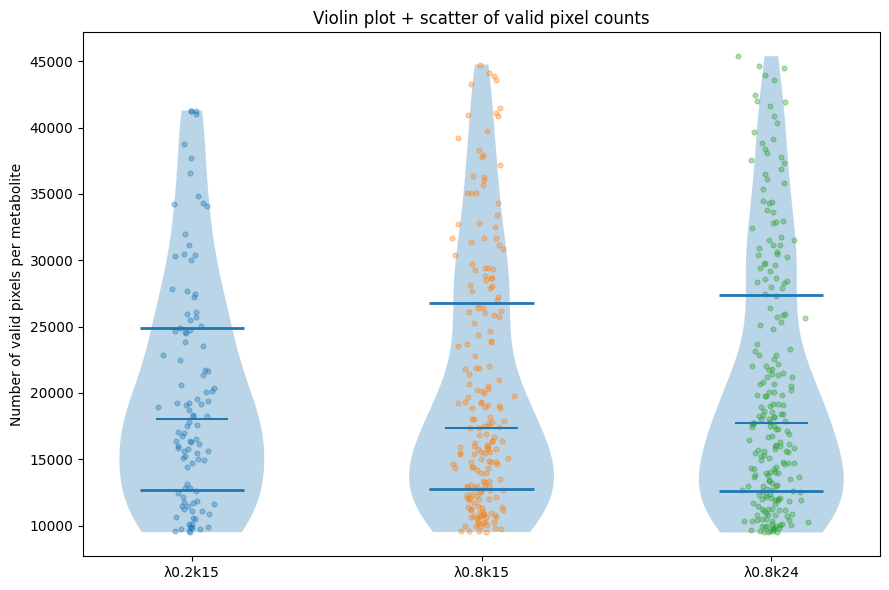

In [22]:


# 取出三组数据
data1 = pd.to_numeric(mz_point_count_df['n_points'], errors='coerce').dropna().values
data2 = pd.to_numeric(mz_point_count_df2['n_points'], errors='coerce').dropna().values
data3 = pd.to_numeric(mz_point_count_df3['n_points'], errors='coerce').dropna().values

data_list = [data1, data2, data3]
labels = ['λ0.2k15', 'λ0.8k15', 'λ0.8k24']
positions = [1, 2, 3]

plt.figure(figsize=(9, 6))

# violin plot
vp = plt.violinplot(
    data_list,
    positions=positions,
    showmeans=False,
    showmedians=True,
    showextrema=False
)

# scatter
for i, data in enumerate(data_list):
    x_jitter = np.random.normal(loc=positions[i], scale=0.04, size=len(data))
    plt.scatter(x_jitter, data, alpha=0.35, s=12)

# 额外画 Q1 和 Q3
for i, data in enumerate(data_list):
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)

    # 横线长度可以自己调
    half_width = 0.18

    plt.hlines(
        y=q1,
        xmin=positions[i] - half_width,
        xmax=positions[i] + half_width,
        linewidth=2
    )
    plt.hlines(
        y=q3,
        xmin=positions[i] - half_width,
        xmax=positions[i] + half_width,
        linewidth=2
    )

# 坐标轴与标题
plt.xticks(positions, labels)
plt.ylabel('Number of valid pixels per metabolite')
plt.title('Violin plot + scatter of valid pixel counts')

plt.tight_layout()
plt.show()